In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils import *

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
data = load_all()
trials = list(iter_trials(data))

In [4]:
# Drop a few input/output variables that are tautological — agents can't
# really get them wrong (every trial × sub-question rated as a perfect
# "match"). Including them would just inflate the Variables block in the
# summary visualization without showing any meaningful variation.
#   sosa2024 Q3  input  — Time from start of trial in seconds
#   sosa2024 Q4  input  — Environment type
#   sosa2024 Q5  input  — Trial number
#   hasnain2024 Q4 output — context
#   hasnain2024 Q5 output — outcome
TAUTOLOGICAL = {
    "sosa2024":    ["3", "4", "5"],
    "hasnain2024": ["4", "5"],
}
for ds, qs in TAUTOLOGICAL.items():
    for q in qs:
        data[ds].pop(q, None)

# Re-derive the flat trial list so downstream cells see the pruned data.
trials = list(iter_trials(data))

### Summary Analysis

In [5]:
# Categorization, layout, and plotting helpers all live in utils.py
# (already brought in via `from utils import *` at the top of the notebook):
#   categorize, collect_rows         — sub-question taxonomy
#   compute_layout                   — shared y-positions across columns
#   draw_dataset_column              — one rating-square column per dataset
#   draw_label_column                — left-margin axes with row/category labels
#   CATEGORY_ORDER, SUBTYPE_ORDER    — fixed top-down section ordering
#   RATING_COLORS                    — rating → color
#
# Edit utils.py to change the taxonomy or visual defaults; the cells below
# only deal with figure layout (figsize, gaps, label positions).

In [6]:
import pandas as pd

# Which rater's ratings drive everything below: the per-trial scores, the
# multi-dataset visualization, the End-to-End rows, and the Average column.
# Options: "best_rating" (combined best per trial — default), "human",
# "claude", or "codex". Set this once at the top; both this cell and the
# multi-dataset cell honor it.
RATING_FIELD = "best_rating"

# Per-trial overall score: collapse each (dataset, agent, trial)'s ratings
# across all non-Code-Efficiency questions into a coarse bucket determined
# by the worst rating in that set. See `compute_trial_scores` in utils.py.
trial_scores = pd.DataFrame(compute_trial_scores(data, rating_field=RATING_FIELD))

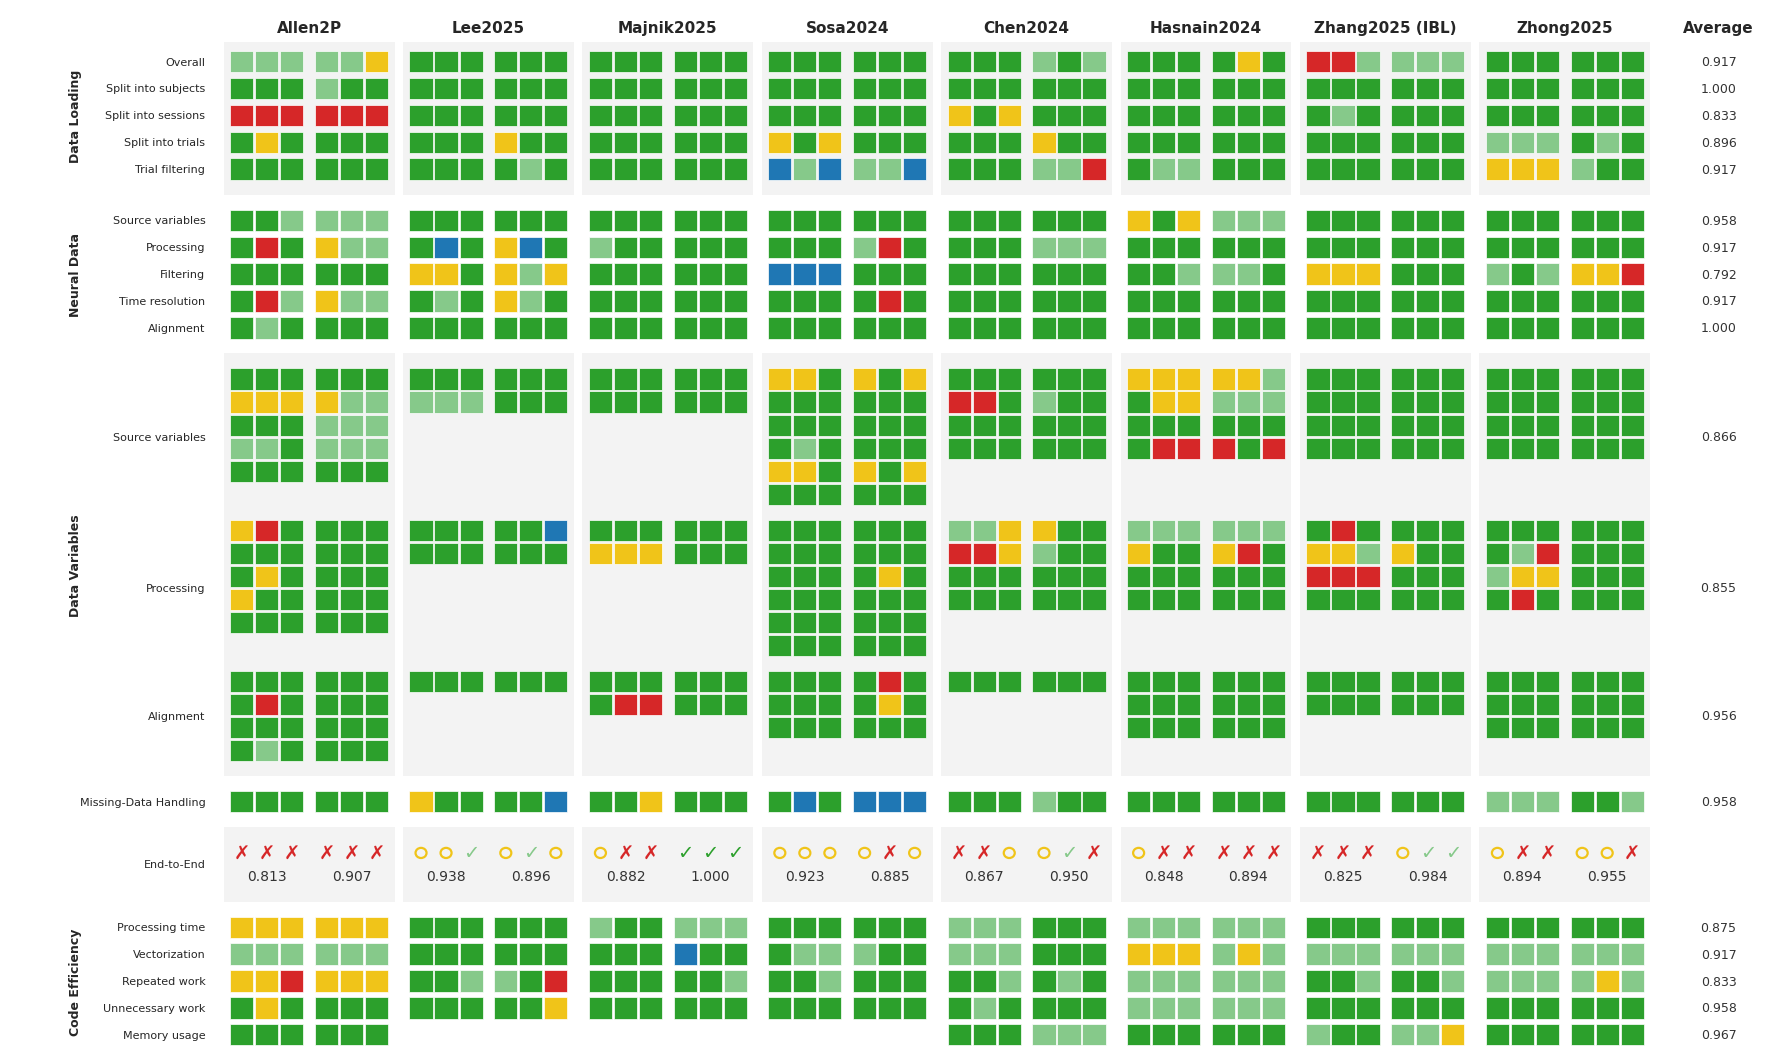

In [7]:
# Custom column order — supervised-behavior datasets first, then the rest.
DATASET_ORDER = [
    "allen2p", "lee2025", "majnik2025", "sosa2024",
    "chen2024", "hasnain2024", "zhang2025", "zhong2025",
]
datasets_sorted = [ds for ds in DATASET_ORDER if ds in data]
n = len(datasets_sorted)

# For each dataset: per-question rows + the two End-to-End summary rows
# (worst-rating symbols + per-agent mean n_ok/n_questions text), spliced
# in just before the Code Efficiency block. RATING_FIELD comes from the
# previous cell — change it there to switch rater (best/human/claude/codex).
all_rows = [
    insert_end_to_end(
        collect_rows(data[ds], rating_field=RATING_FIELD),
        end_to_end_rows(ds, trial_scores),
    )
    for ds in datasets_sorted
]

# Per-(category, subtype) grand-average proportion of correct (≥ ok) ratings,
# pooled across all datasets, agents, trials, and (for Data Variables)
# variables. End-to-End is excluded by default — see `compute_subtype_summary`
# in utils.py.
summary = compute_subtype_summary(all_rows)

# Display-only label overrides for column titles (the underlying dataset keys
# in `data` are unchanged).
DISPLAY_NAME = {
    "allen2p":   "Allen2P",
    "zhang2025": "Zhang2025 (IBL)",
}
def display_name(ds):
    return DISPLAY_NAME.get(ds, ds[:1].upper() + ds[1:])

# Single shared layout — every column places its rows at the same y for any
# given (category, subtype, slot). Subtype slots are sized to the dataset that
# has the most rows in that slot; shorter datasets leave gaps.
# Tight subtype gap for the small categories (Data Loading, Neural Data, Code
# Efficiency) but a larger gap inside the Data Variables block where stacked
# sub-types (Source variables / Processing / Alignment) need breathing room.
layout = compute_layout(all_rows, subtype_gap={"Data Variables": 0.5, "*": 0.15})

# Layout: 1 label axes + n IDENTICAL data axes + 1 summary axes. We drop
# aspect="equal" on the data axes so each one fills its gridspec slot
# vertically; we instead size the figure so the natural axes box already
# matches the data range ratio, accounting for figure margins and subplot
# spacing so cells stay square.
data_y_range = layout["y_top"] - layout["y_bot"] + 1.6 + 0.3   # incl. title pad
data_x_range = 6 * layout["square"] + 0.35 + 0.4               # 6 cells + agent gap + pad
left, right, top, bottom, wspace = 0.02, 0.99, 0.97, 0.02, 0.05
label_w_ratio = 1.2                                            # label axes / data axes width
summary_w_ratio = 0.7                                          # summary axes / data axes width
cell_aspect_fudge = 1.08                                       # >1 widens cells (perceptually squarer)
cell_size_frac = 0.925                                         # <1 shrinks each cell to leave a gap

fig_h_in = 11.0
axes_h_in = fig_h_in * (top - bottom)                          # phys h of one axes
data_axes_w = axes_h_in / (data_y_range / data_x_range) * cell_aspect_fudge
total_axes_w = (label_w_ratio + n + summary_w_ratio) * data_axes_w * (1 + wspace)
fig_w_in = total_axes_w / (right - left)

fig, axes = plt.subplots(
    1, n + 2, figsize=(fig_w_in, fig_h_in), sharey=True,
    gridspec_kw={"width_ratios": [label_w_ratio] + [1.0] * n + [summary_w_ratio]},
)
fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom, wspace=wspace)

# category_label_x bumped right so the rotated category headers sit just
# beside the subtype labels instead of all the way at the left edge.
draw_label_column(axes[0], layout, category_label_x=0.3)

for ax, ds, rows in zip(axes[1:-1], datasets_sorted, all_rows):
    draw_dataset_column(
        ax, rows, layout,
        title=display_name(ds), show_labels=False, keep_aspect=False,
        cell_size_frac=cell_size_frac,
    )

# Rightmost column: per-subtype grand-average fraction of correct ratings.
draw_summary_column(axes[-1], layout, summary, title="Average")

plt.show()

### Evaluate Evaluation

In [8]:
# Build a long-format frame of all four "rater" decisions (human, claude
# judge, codex judge, best-resolved) in matched order so we can compare
# their distributions and inter-rater agreement.
#
# Inclusion criteria:
#   - Skip the Code Efficiency category (soft advice, not a correctness check).
#   - Skip questions that don't categorize into the fixed taxonomy
#     (defensive — currently every question maps to a category).
#   - Tautological variables (sosa2024 Q3-5, hasnain2024 Q4-5) are already
#     absent from `data` thanks to the TAUTOLOGICAL pruning cell above, so
#     they automatically drop out here too.
#
# One row per (dataset, qid, agent, trial) — six trial rows per question
# per dataset. The four rater columns are aligned, so e.g.
# `eval_quality.iloc[0][["human", "claude", "codex", "best"]]` are the
# four decisions on the same trial.

EVAL_QUALITY_EXCLUDE = {"Code Efficiency"}

records = []
for ds, mains in data.items():
    for main, subs in mains.items():
        for sub_letter, q in subs.items():
            qid = f"{main}-{sub_letter}" if sub_letter else main
            cat = categorize(qid, q["title"])
            if cat is None or cat[0] in EVAL_QUALITY_EXCLUDE:
                continue
            for i, agent in enumerate(q["agents"]):
                records.append({
                    "dataset": ds,
                    "qid": qid,
                    "category": cat[0],
                    "subtype": cat[1],
                    "agent": agent,
                    "trial": int(q["trials"][i]),
                    "human":  q["human"][i],
                    "claude": q["claude"][i],
                    "codex":  q["codex"][i],
                    "best":   q["best_rating"][i],
                })

eval_quality = pd.DataFrame(records)
print(f"{len(eval_quality)} (dataset, qid, agent, trial) rows × 4 raters "
      f"(human / claude / codex / best)")
eval_quality.head(10)

1014 (dataset, qid, agent, trial) rows × 4 raters (human / claude / codex / best)


,dataset,qid,category,subtype,agent,trial,human,claude,codex,best
0,allen2p,1-a,Data Loading,Overall,claude-code,1,0.0,0.0,-2.0,0.0
1,allen2p,1-a,Data Loading,Overall,claude-code,2,0.0,0.0,-2.0,0.0
2,allen2p,1-a,Data Loading,Overall,claude-code,3,0.0,0.0,-2.0,0.0
3,allen2p,1-a,Data Loading,Overall,codex,1,0.0,0.0,-2.0,0.0
4,allen2p,1-a,Data Loading,Overall,codex,2,0.0,0.0,-2.0,0.0
5,allen2p,1-a,Data Loading,Overall,codex,3,0.0,-1.0,-2.0,-1.0
6,allen2p,1-b,Data Loading,Split into subjects,claude-code,1,1.0,1.0,1.0,1.0
7,allen2p,1-b,Data Loading,Split into subjects,claude-code,2,1.0,1.0,1.0,1.0
8,allen2p,1-b,Data Loading,Split into subjects,claude-code,3,1.0,1.0,1.0,1.0
9,allen2p,1-b,Data Loading,Split into subjects,codex,1,0.0,1.0,1.0,0.0


In [9]:
# Split eval_quality into the two dataset families. We expect the two groups
# to behave differently (the unsupervised side has more open-ended choices,
# so judges and humans may disagree more often).
SUPERVISED   = {"allen2p", "lee2025", "majnik2025", "sosa2024"}
UNSUPERVISED = {"chen2024", "hasnain2024", "zhang2025", "zhong2025"}

eq_supervised   = eval_quality[eval_quality["dataset"].isin(SUPERVISED)].reset_index(drop=True)
eq_unsupervised = eval_quality[eval_quality["dataset"].isin(UNSUPERVISED)].reset_index(drop=True)

print(f"Supervised   : {len(eq_supervised):4d} rows  ({sorted(eq_supervised['dataset'].unique())})")
print(f"Unsupervised : {len(eq_unsupervised):4d} rows  ({sorted(eq_unsupervised['dataset'].unique())})")

Supervised   :  504 rows  (['allen2p', 'lee2025', 'majnik2025', 'sosa2024'])
Unsupervised :  510 rows  (['chen2024', 'hasnain2024', 'zhang2025', 'zhong2025'])


In [10]:
# Decision-correlation between each rater and the resolved best rating, for
# each split. Three complementary measures (NaN pairs dropped):
#   pearson    treats the rating scale -2..2 as continuous (linear agreement)
#   spearman   rank-based, respects ordinal nature of the scale
#   exact      fraction of trials where rater == best (strict identity)
#
# Note: by construction `best` defaults to the human rating unless the user
# flagged the LLM judge as more accurate, so (human vs best) will already be
# very close to 1.0 — that row is the "ceiling" baseline.

from scipy.stats import pearsonr, spearmanr

def rater_vs_best(df, rater):
    pair = df[[rater, "best"]].dropna()
    if len(pair) < 2:
        return float("nan"), float("nan"), float("nan"), 0
    return (
        pearsonr(pair[rater], pair["best"]).statistic,
        spearmanr(pair[rater], pair["best"]).statistic,
        (pair[rater] == pair["best"]).mean(),
        len(pair),
    )

def print_table(name, df):
    print(f"\n{name}  (n_total={len(df)})")
    print(f"  {'rater':10s}  {'pearson':>8s}  {'spearman':>9s}  {'exact':>7s}  n_pairs")
    print(f"  {'-'*10}  {'-'*8}  {'-'*9}  {'-'*7}  -------")
    for rater in ("human", "claude", "codex"):
        p, s, e, n = rater_vs_best(df, rater)
        print(f"  {rater:10s}  {p:>8.3f}  {s:>9.3f}  {e:>7.3f}  {n:>7d}")

print_table("ALL DATA",            eval_quality)
print_table("Supervised (4 ds)",   eq_supervised)
print_table("Unsupervised (4 ds)", eq_unsupervised)


ALL DATA  (n_total=1014)
  rater        pearson   spearman    exact  n_pairs
  ----------  --------  ---------  -------  -------
  human          0.977      0.976    0.991     1014
  claude         0.334      0.335    0.708     1014
  codex          0.269      0.262    0.566     1014

Supervised (4 ds)  (n_total=504)
  rater        pearson   spearman    exact  n_pairs
  ----------  --------  ---------  -------  -------
  human          0.953      0.954    0.982      504
  claude         0.435      0.425    0.643      504
  codex          0.302      0.300    0.419      504

Unsupervised (4 ds)  (n_total=510)
  rater        pearson   spearman    exact  n_pairs
  ----------  --------  ---------  -------  -------
  human          1.000      1.000    1.000      510
  claude         0.235      0.273    0.773      510
  codex          0.309      0.323    0.712      510


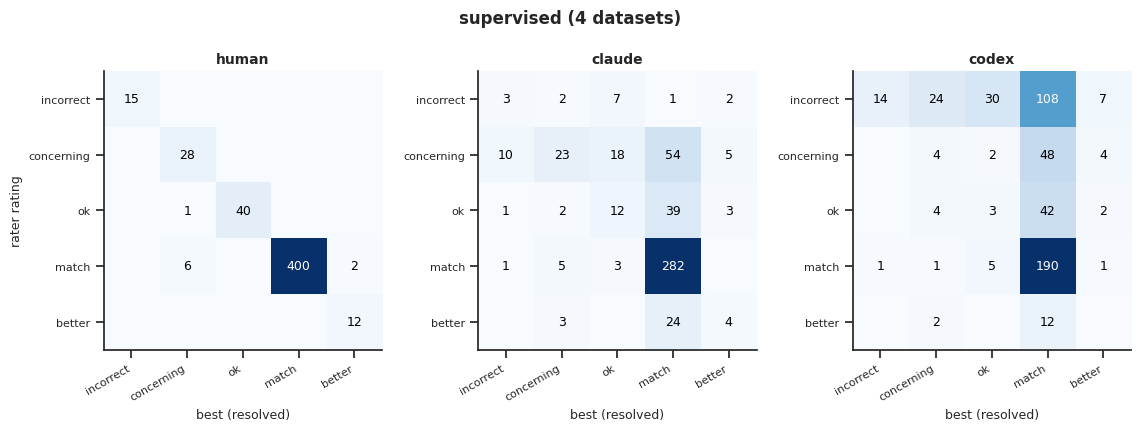

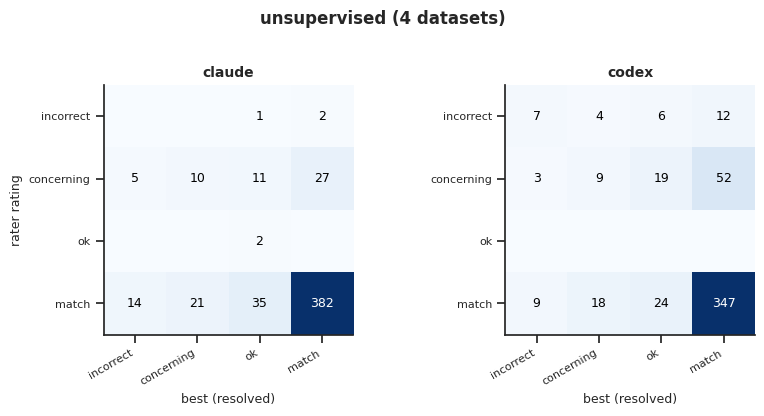

In [11]:
# Fine-grained confusion matrices: rater rating vs the resolved `best`,
# one heatmap per rater. Diagonal cells = perfect agreement; off-diagonal
# mass shows where each rater drifts from the user's call.
# Split into two separate figures because the "better" rating only ever
# shows up in the supervised datasets — unsupervised drops that row/column.
# Human is also dropped from the unsupervised side: no separate human eval
# was done there, so best == human by construction (trivially diagonal).

LEVEL_NAMES = {
    -2: "incorrect", -1: "concerning", 0: "ok", 1: "match", 2: "better",
}

def confusion_matrix(df, rater, levels):
    pair = df[[rater, "best"]].dropna()
    cm = np.zeros((len(levels), len(levels)), dtype=int)
    idx = {v: i for i, v in enumerate(levels)}
    for r, b in zip(pair[rater], pair["best"]):
        if int(r) in idx and int(b) in idx:
            cm[idx[int(r)], idx[int(b)]] += 1
    return cm

def draw_confusion_grid(df, levels, title, raters):
    n_lev = len(levels)
    fig, axes = plt.subplots(1, len(raters),
                             figsize=(2.0 + 3.2 * len(raters), 4.0),
                             squeeze=False)
    axes = axes[0]
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    for col, rater in enumerate(raters):
        ax = axes[col]
        cm = confusion_matrix(df, rater, levels)
        ax.imshow(cm, cmap="Blues")
        vmax = cm.max() if cm.max() else 1
        for i in range(n_lev):
            for j in range(n_lev):
                v = cm[i, j]
                if v == 0:
                    continue
                color = "white" if v > 0.55 * vmax else "black"
                ax.text(j, i, str(v), ha="center", va="center",
                        fontsize=9, color=color)
        names = [LEVEL_NAMES[v] for v in levels]
        ax.set_xticks(range(n_lev))
        ax.set_yticks(range(n_lev))
        ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
        ax.set_yticklabels(names, fontsize=8)
        ax.set_title(rater, fontsize=10, fontweight="bold")
        ax.set_xlabel("best (resolved)", fontsize=9)
        if col == 0:
            ax.set_ylabel("rater rating", fontsize=9)
    plt.tight_layout()
    plt.show()

# Supervised: full 5-level scale (some trials reach "better").
draw_confusion_grid(eq_supervised, levels=(-2, -1, 0, 1, 2),
                    title="supervised (4 datasets)",
                    raters=("human", "claude", "codex"))

# Unsupervised: drops "better" — never used by any rater on this side.
# Drops human — best == human there (no separate human eval was done).
draw_confusion_grid(eq_unsupervised, levels=(-2, -1, 0, 1),
                    title="unsupervised (4 datasets)",
                    raters=("claude", "codex"))

In [20]:
# Binary accuracy: collapse the 5-level rating into a 2-level decision
#   correct   = rating ≥ 0  (ok / match / better)        ← positive class
#   incorrect = rating ≤ -1 (concerning / incorrect)     ← negative class
# Then compare each rater (predictor) to `best` (ground truth). Standard
# confusion-matrix labels with "correct" as the positive class:
#   TP   rater correct,   best correct        agreement on correct
#   FP   rater correct,   best incorrect      rater missed a real problem
#   FN   rater incorrect, best correct        rater flagged a non-issue
#   TN   rater incorrect, best incorrect      agreement on incorrect
# Headline numbers (all reduce to single-number summaries of the 2×2 table):
#   accuracy   = (TP + TN) / n        — raw fraction; biased by class prior
#   bal_acc    = (sens + spec) / 2    — accuracy if the two classes were
#                                       reweighted to be equal
#   d-prime    = z(hit) − z(fa)       — signal-detection separation between
#                                       "correct" and "incorrect"; uses the
#                                       Hautus log-linear correction so rates
#                                       at 0/1 don't blow up to ±inf
# Each cell shows raw count + proportion of n.
# Human is dropped from the unsupervised side (best == human there).

from scipy.stats import norm

def binary_table(df, rater):
    pair = df[[rater, "best"]].dropna()
    r_ok = pair[rater] >= 0
    b_ok = pair["best"] >= 0
    TP = int(( r_ok &  b_ok).sum())
    FP = int(( r_ok & ~b_ok).sum())
    FN = int((~r_ok &  b_ok).sum())
    TN = int((~r_ok & ~b_ok).sum())
    n  = TP + FP + FN + TN
    acc  = (TP + TN) / n if n else float("nan")
    sens = TP / (TP + FN) if (TP + FN) else float("nan")
    spec = TN / (TN + FP) if (TN + FP) else float("nan")
    bal  = (sens + spec) / 2 if (TP + FN) and (TN + FP) else float("nan")
    # Hautus log-linear correction for d'.
    hit  = (TP + 0.5) / (TP + FN + 1)
    fa   = (FP + 0.5) / (FP + TN + 1)
    dp   = norm.ppf(hit) - norm.ppf(fa)
    return acc, bal, dp, TP, FP, FN, TN, n

def fmt_cell(count, n):
    return f"{count:>3d} ({count / n * 100:>4.1f}%)" if n else "  - (   - )"

def print_binary(name, df, raters):
    print(f"\n{name}  (n_total={len(df)})")
    print(f"  {'rater':10s}  {'acc':>5s}  {'bal_acc':>7s}  {'d-prime':>7s}    "
          f"{'TP':>11s} {'FP':>11s} {'FN':>11s} {'TN':>11s}    n")
    print(f"  {'-'*10}  {'-'*5}  {'-'*7}  {'-'*7}    "
          f"{'-'*11} {'-'*11} {'-'*11} {'-'*11}   ---")
    for rater in raters:
        acc, bal, dp, TP, FP, FN, TN, n = binary_table(df, rater)
        print(f"  {rater:10s}  {acc:>5.3f}  {bal:>7.3f}  {dp:>7.3f}    "
              f"{fmt_cell(TP, n)} {fmt_cell(FP, n)} "
              f"{fmt_cell(FN, n)} {fmt_cell(TN, n)}   {n:>3d}")

print("Binary decision: correct (≥ ok) vs incorrect (≤ concerning).  Positive class = correct.")
print("  TP = both correct                | FP = rater correct,   best incorrect (missed problem)")
print("  FN = rater incorrect, best correct (false alarm) | TN = both incorrect")
print_binary("Supervised (4 ds)",   eq_supervised,   raters=("human", "claude", "codex"))
print_binary("Unsupervised (4 ds)", eq_unsupervised, raters=("claude", "codex"))

Binary decision: correct (≥ ok) vs incorrect (≤ concerning).  Positive class = correct.
  TP = both correct                | FP = rater correct,   best incorrect (missed problem)
  FN = rater incorrect, best correct (false alarm) | TN = both incorrect

Supervised (4 ds)  (n_total=504)
  rater         acc  bal_acc  d-prime             TP          FP          FN          TN    n
  ----------  -----  -------  -------    ----------- ----------- ----------- -----------   ---
  human       0.986    0.930    4.111    454 (90.1%)   7 ( 1.4%)   0 ( 0.0%)  43 ( 8.5%)   504
  claude      0.804    0.784    1.559    367 (72.8%)  12 ( 2.4%)  87 (17.3%)  38 ( 7.5%)   504
  codex       0.589    0.701    1.122    255 (50.6%)   8 ( 1.6%) 199 (39.5%)  42 ( 8.3%)   504

Unsupervised (4 ds)  (n_total=510)
  rater         acc  bal_acc  d-prime             TP          FP          FN          TN    n
  ----------  -----  -------  -------    ----------- ----------- ----------- -----------   ---
  claude      0

In [21]:
# Mistake-catching metrics: how well does each LLM judge flag the trials
# that the user (`best`) marked as `incorrect / concerning` (rating ≤ -1)?
#
# Same binary collapse as above, but now "incorrect" is the POSITIVE class
# (mistake = positive event we want to catch). Confusion-matrix counts vs
# `best` as ground truth:
#   TP = both flag incorrect            — caught a real mistake
#   FP = judge incorrect, best correct  — false alarm (flagged a non-issue)
#   FN = judge correct,   best incorrect — missed a real mistake
#   TN = both correct                   — correctly left alone
#
# Reported metrics:
#   recall      = TP / (TP + FN)   fraction of real mistakes caught
#   precision   = TP / (TP + FP)   when judge flags, how often it's right
#   specificity = TN / (TN + FP)   fraction of correct trials left alone
#   F1          = 2 P R / (P + R)
# Human is dropped from the unsupervised side (best == human there).

def catch_metrics(df, rater):
    pair = df[[rater, "best"]].dropna()
    r_bad = pair[rater] <= -1     # judge calls it a mistake
    b_bad = pair["best"]  <= -1   # ground truth: it is a mistake
    TP = int(( r_bad &  b_bad).sum())
    FP = int(( r_bad & ~b_bad).sum())
    FN = int((~r_bad &  b_bad).sum())
    TN = int((~r_bad & ~b_bad).sum())
    n_mistakes = TP + FN
    rec  = TP / n_mistakes        if n_mistakes        else float("nan")
    prec = TP / (TP + FP)         if (TP + FP)         else float("nan")
    spec = TN / (TN + FP)         if (TN + FP)         else float("nan")
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else float("nan")
    return rec, prec, spec, f1

def print_catch(name, df, raters):
    print(f"\n{name}  (n_total={len(df)})")
    print(f"  {'rater':10s}  {'recall':>7s}  {'precision':>9s}  "
          f"{'specificity':>11s}  {'F1':>5s}")
    print(f"  {'-'*10}  {'-'*7}  {'-'*9}  {'-'*11}  {'-'*5}")
    for r in raters:
        rec, prec, spec, f1 = catch_metrics(df, r)
        print(f"  {r:10s}  {rec:>7.3f}  {prec:>9.3f}  "
              f"{spec:>11.3f}  {f1:>5.3f}")

print("Catching mistakes — positive class = incorrect (rating ≤ -1).")
print("  recall = caught mistakes / actual mistakes  (the headline metric)")
print("  precision = mistakes among the things you flagged")
print("  specificity = unflagged correct trials / actual correct trials")
print_catch("Supervised (4 ds)",   eq_supervised,   raters=("human", "claude", "codex"))
print_catch("Unsupervised (4 ds)", eq_unsupervised, raters=("claude", "codex"))

Catching mistakes — positive class = incorrect (rating ≤ -1).
  recall = caught mistakes / actual mistakes  (the headline metric)
  precision = mistakes among the things you flagged
  specificity = unflagged correct trials / actual correct trials

Supervised (4 ds)  (n_total=504)
  rater        recall  precision  specificity     F1
  ----------  -------  ---------  -----------  -----
  human         0.860      1.000        1.000  0.925
  claude        0.760      0.304        0.808  0.434
  codex         0.840      0.174        0.562  0.289

Unsupervised (4 ds)  (n_total=510)
  rater        recall  precision  specificity     F1
  ----------  -------  ---------  -----------  -----
  claude        0.300      0.268        0.911  0.283
  codex         0.460      0.205        0.807  0.284


In [ ]:
# Full judge × agent breakdown — all four (judge, target-agent) pairings:
#   claude-code → claude-code   (self)
#   claude-code → codex         (cross)
#   codex       → claude-code   (cross)
#   codex       → codex         (self)
# Same two summaries as above (binary accuracy + mistake-catching), but
# each row is filtered to the named target agent's trials only. Reuses
# `binary_table` / `catch_metrics` / `fmt_cell` defined above.
#
# Note: the rater column in `eval_quality` is "claude" (short name), but
# we display it as "claude-code" so judge and target agent share the same
# naming convention in the printout.

# (rater_col_in_df, judge_display_label, target_agent_value)
JUDGE_AGENT_PAIRS = [
    ("claude", "claude-code", "claude-code"),
    ("claude", "claude-code", "codex"),
    ("codex",  "codex",       "claude-code"),
    ("codex",  "codex",       "codex"),
]

def print_binary_pairs(name, df):
    print(f"\n{name}  (n_total={len(df)})")
    print(f"  {'judge → agent':28s}  {'acc':>5s}  {'bal_acc':>7s}  {'d-prime':>7s}    "
          f"{'TP':>11s} {'FP':>11s} {'FN':>11s} {'TN':>11s}    n")
    print(f"  {'-'*28}  {'-'*5}  {'-'*7}  {'-'*7}    "
          f"{'-'*11} {'-'*11} {'-'*11} {'-'*11}   ---")
    for rater_col, judge_label, target in JUDGE_AGENT_PAIRS:
        sub = df[df["agent"] == target]
        if sub.empty:
            continue
        acc, bal, dp, TP, FP, FN, TN, n = binary_table(sub, rater_col)
        label = f"{judge_label} → {target}"
        print(f"  {label:28s}  {acc:>5.3f}  {bal:>7.3f}  {dp:>7.3f}    "
              f"{fmt_cell(TP, n)} {fmt_cell(FP, n)} "
              f"{fmt_cell(FN, n)} {fmt_cell(TN, n)}   {n:>3d}")

def print_catch_pairs(name, df):
    print(f"\n{name}  (n_total={len(df)})")
    print(f"  {'judge → agent':28s}  {'recall':>7s}  {'precision':>9s}  "
          f"{'specificity':>11s}  {'F1':>5s}")
    print(f"  {'-'*28}  {'-'*7}  {'-'*9}  {'-'*11}  {'-'*5}")
    for rater_col, judge_label, target in JUDGE_AGENT_PAIRS:
        sub = df[df["agent"] == target]
        if sub.empty:
            continue
        rec, prec, spec, f1 = catch_metrics(sub, rater_col)
        label = f"{judge_label} → {target}"
        print(f"  {label:28s}  {rec:>7.3f}  {prec:>9.3f}  "
              f"{spec:>11.3f}  {f1:>5.3f}")

print("=== Judge × agent: binary accuracy (positive class = correct) ===")
print_binary_pairs("Supervised (4 ds)",   eq_supervised)
print_binary_pairs("Unsupervised (4 ds)", eq_unsupervised)

print("\n\n=== Judge × agent: mistake-catching (positive class = incorrect) ===")
print_catch_pairs("Supervised (4 ds)",   eq_supervised)
print_catch_pairs("Unsupervised (4 ds)", eq_unsupervised)

### Agent Performance

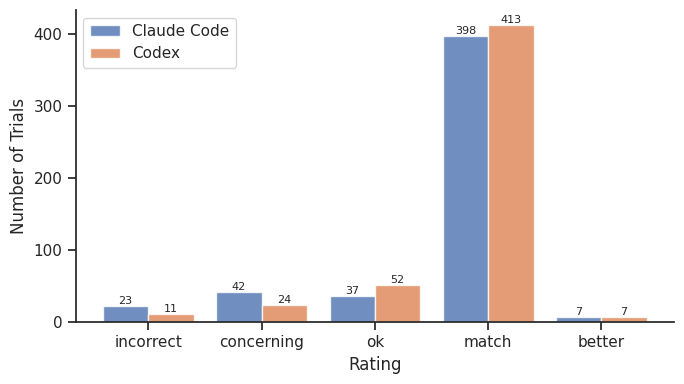

In [14]:
# Per-agent count of trial × sub-question rows at each rating level.
# Uses `eval_quality` so Code Efficiency and tautological vars are already
# excluded; the resolved `best` rating is the per-row score.

LEVELS = (-2, -1, 0, 1, 2)
LEVEL_NAMES = {-2: "incorrect", -1: "concerning", 0: "ok",
                1: "match",     2: "better"}

def counts_by_level(df, agent):
    s = df.loc[df["agent"] == agent, "best"].dropna().astype(int)
    return np.array([(s == lv).sum() for lv in LEVELS])

claude_counts = counts_by_level(eval_quality, "claude-code")
codex_counts  = counts_by_level(eval_quality, "codex")

x = np.arange(len(LEVELS))
width = 0.4

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, claude_counts, width, label="Claude Code",
       color="C0", alpha=0.8)
ax.bar(x + width / 2, codex_counts,  width, label="Codex",
       color="C1", alpha=0.8)

for i, (c, k) in enumerate(zip(claude_counts, codex_counts)):
    ax.text(i - width / 2, c, str(c), ha="center", va="bottom", fontsize=8)
    ax.text(i + width / 2, k, str(k), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([LEVEL_NAMES[lv] for lv in LEVELS])
ax.set_xlabel("Rating")
ax.set_yticks(range(0, 401, 100))
ax.set_ylabel("Number of Trials")
ax.legend()

plt.tight_layout()
plt.show()

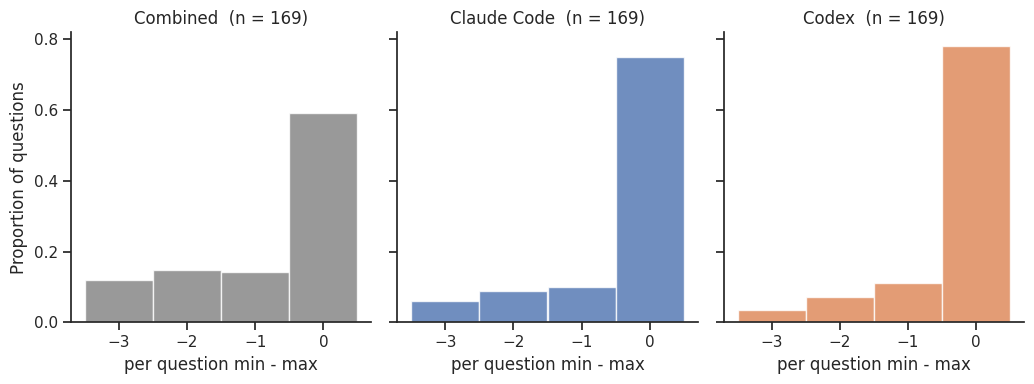

In [15]:
# Trial variability — plot 1: per sub-question, the spread (min − max) of
# `best` ratings across its trials. One data point per sub-question.
#   - Combined: all trials of both agents (6 per sub-q)
#   - Claude-Code only: 3 trials per sub-q
#   - Codex only:       3 trials per sub-q
# Spread is ≤ 0; 0 means all trials agreed exactly.

def spread_per_subq(df):
    g = df.groupby(["dataset", "qid"])["best"]
    return (g.min() - g.max()).dropna().to_numpy()

combined_spread = spread_per_subq(eval_quality)
claude_spread   = spread_per_subq(eval_quality[eval_quality["agent"] == "claude-code"])
codex_spread    = spread_per_subq(eval_quality[eval_quality["agent"] == "codex"])

bins = np.arange(-3.5, 1.5, 1)
panels = [
    ("Combined",    combined_spread, "gray"),
    ("Claude Code", claude_spread,   "C0"),
    ("Codex",       codex_spread,    "C1"),
]

fig, axs = plt.subplots(1, 3, figsize=(10.5, 4), sharey=True)
for ax, (label, vals, color) in zip(axs, panels):
    ax.hist(vals, bins=bins, color=color, alpha=0.8, density=True)
    ax.set_xlabel("per question min - max")
    ax.set_title(f"{label}  (n = {len(vals)})")
    ax.set_xticks(np.arange(-3, 1))
    ax.set_yticks(np.arange(0, 0.81, 0.2))
axs[0].set_ylabel("Proportion of questions")

plt.tight_layout()
plt.show()

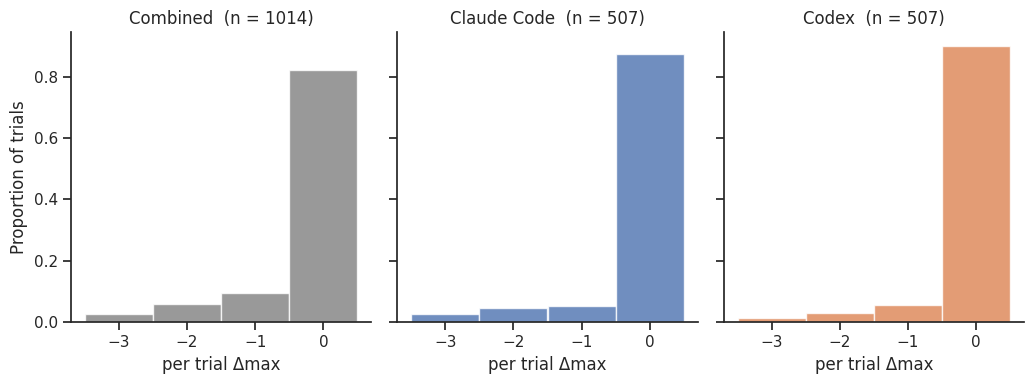

In [16]:
# Trial variability — plot 2: per sub-question, each trial's `best` rating
# minus the max across trials in that sub-question. n trials per sub-q,
# so total points = (n_subq × n_trials_per_subq).
#   - Combined: 6 trials per sub-q (both agents)
#   - Claude-Code only: 3 trials per sub-q
#   - Codex only:       3 trials per sub-q
# 0 = trial achieved the per-sub-q best; negative = below best.

def trial_minus_max(df):
    g = df.groupby(["dataset", "qid"])["best"]
    return (df["best"] - g.transform("max")).dropna().to_numpy()

combined_dmax = trial_minus_max(eval_quality)
claude_dmax   = trial_minus_max(eval_quality[eval_quality["agent"] == "claude-code"])
codex_dmax    = trial_minus_max(eval_quality[eval_quality["agent"] == "codex"])

bins = np.arange(-3.5, 1.5, 1)
panels = [
    ("Combined",    combined_dmax, "gray"),
    ("Claude Code", claude_dmax,   "C0"),
    ("Codex",       codex_dmax,    "C1"),
]

fig, axs = plt.subplots(1, 3, figsize=(10.5, 4), sharey=True)
for ax, (label, vals, color) in zip(axs, panels):
    ax.hist(vals, bins=bins, color=color, alpha=0.8, density=True)
    ax.set_xlabel("per trial Δmax")
    ax.set_title(f"{label}  (n = {len(vals)})")
    ax.set_xticks(np.arange(-3, 1))
axs[0].set_ylabel("Proportion of trials")

plt.tight_layout()
plt.show()

In [17]:
# "Best-of-3" end-to-end: for each (dataset, agent, sub-question) take the
# max `best` rating across the 3 trials, then collapse across sub-questions
# the same way the End-to-End rows do — worst rating across sub-qs, plus
# count of sub-qs at ≥ ok. Shows what the per-dataset summary would look
# like if we got to pick the better trial per sub-question.
# Compare against the per-trial rows in `trial_scores` from earlier.

BUCKETS = [(-1.5, "has incorrect"), (-0.5, "≥ concerning"),
           ( 0.5, "≥ ok"),          ( 1.5, "≥ match"),
           (np.inf, "≥ better")]

def bucket_of(min_r):
    for thresh, name in BUCKETS:
        if min_r < thresh:
            return name
    return BUCKETS[-1][1]

best_of_3 = (
    eval_quality
    .groupby(["dataset", "agent", "qid"])["best"]
    .max()
    .reset_index()
)

records = []
for (ds, agent), g in best_of_3.groupby(["dataset", "agent"]):
    n_q  = len(g)
    n_ok = int((g["best"] >= 0).sum())
    mn   = g["best"].min()
    records.append({
        "dataset": ds, "agent": agent,
        "n_questions": n_q, "n_ok": n_ok,
        "min_rating": mn, "bucket": bucket_of(mn),
    })

best_of_3_summary = (
    pd.DataFrame(records)
    .sort_values(["dataset", "agent"])
    .reset_index(drop=True)
)

In [18]:
# Best-of-3 end-to-end — one column per dataset, dataset title above,
# two glyphs (claude-code  codex) below. Glyphs are colored by rating
# using ANSI escape codes (approximates the RATING_COLORS palette from
# utils.py: blue / green / lt-green / yellow / red).

import re

ANSI_RE = re.compile(r"\x1b\[[0-9;]*m")
ANSI_RESET = "\033[0m"
ANSI_BY_RATING = {
     2: "\033[34m",   # blue          — better
     1: "\033[32m",   # green         — match
     0: "\033[92m",   # bright green  — ok
    -1: "\033[33m",   # yellow        — concerning
    -2: "\033[31m",   # red           — incorrect
}

def colored_symbol(min_r):
    if min_r is None or (isinstance(min_r, float) and np.isnan(min_r)):
        return " "
    if min_r >= 0:    sym = "✓"
    elif min_r >= -1: sym = "○"
    else:             sym = "✗"
    return f"{ANSI_BY_RATING.get(int(min_r), '')}{sym}{ANSI_RESET}"

def visible_len(s):
    return len(ANSI_RE.sub("", s))

def vis_center(s, width):
    pad = max(0, width - visible_len(s))
    left = pad // 2
    return " " * left + s + " " * (pad - left)

ds_cols = [ds for ds in DATASET_ORDER
           if ds in best_of_3_summary["dataset"].unique()]

titles, glyphs = [], []
for ds in ds_cols:
    syms = []
    for agent in ("claude-code", "codex"):
        sub = best_of_3_summary[
            (best_of_3_summary.dataset == ds)
            & (best_of_3_summary.agent == agent)
        ]
        syms.append(colored_symbol(sub.iloc[0]["min_rating"])
                    if not sub.empty else " ")

    title = display_name(ds)
    cell  = f"{syms[0]}   {syms[1]}"   # gap between the two glyphs
    width = max(len(title), visible_len(cell))
    titles.append(title.center(width))
    glyphs.append(vis_center(cell, width))

print("   ".join(titles))
print("   ".join(glyphs))

Allen2P   Lee2025   Majnik2025   Sosa2024   Chen2024   Hasnain2024   Zhang2025 (IBL)   Zhong2025
 ✗   ✗     ✓   ✓      ○   ✓       ✓   ✓      ○   ✓        ○   ✓           ✗   ✓          ○   ○  
